# 3 — Conditional queries and stress testing

Tail dependence coefficients are the right way to *compare* copulas, but they are a poor way
to *communicate* risk. "λ_L = 0.71" means little to someone deciding how much capital to hold.

This notebook is about the translation: turning a fitted copula into direct answers to
questions like *"if the front contract gaps 5% overnight, what happens to the rest of the
book?"* — the shape of a stress test.

## How conditioning works here

The flow is fitted **unconditionally**: it learns $p(x_1, \dots, x_d)$ with no designated
input variable. So conditioning is done by importance-weighted resampling:

1. Draw a large sample from the fitted joint.
2. Weight each draw by a Gaussian kernel around the conditioning value, measured in the
   flow's own space (where distances are comparable across columns).
3. Read off the weighted distribution of the target.

The advantage is that **any** subset of columns can be conditioned on, in any direction,
without refitting. The cost is a bandwidth choice (`tol`) and Monte Carlo noise — which is
why every method reports an **effective sample size** you are expected to check.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neurocopula import NeuroCopula, datasets, plotting as ncplot, theme

pd.set_option("display.width", 130, "display.precision", 4)

# Apply the library's visual theme, so hand-rolled figures in this notebook
# match the ones the library produces. rcParams are read when an Axes is
# created, so this must run before any plotting.
theme.apply_theme()

## A small book

Five instruments: two grain contracts that move together, two metals that move together, a
weak link between the blocks, and an FX series that is nearly independent. Fat tails and
genuine tail dependence throughout.

In [2]:
df = datasets.make_asset_panel(n=4000, seed=0)

model = NeuroCopula(
    transforms=4, hidden_features=(64, 64),
    copula_mode=True,
    sampling_mode="coupling",   # parallel sampling: every query below draws large samples
    seed=0,
).fit(df, epochs=700, patience=60, split_method="random", verbose=False)

print(model)
print(f"overfit gap: {model.fit_report_['overfit_gap']:+.3f}")
df.corr().round(2)

NeuroCopula(transforms=4, hidden_features=(64, 64), copula_mode=True, bayesian=False, fitted on 4000 rows x 5 cols)
overfit gap: +0.226


,grain_A,grain_B,metal_A,metal_B,fx_A
grain_A,1.00,0.75,0.10,0.05,0.00
grain_B,0.75,1.00,0.04,0.08,-0.02
metal_A,0.10,0.04,1.00,0.65,0.19
metal_B,0.05,0.08,0.65,1.00,0.18
fx_A,0.00,-0.02,0.19,0.18,1.00


## The bandwidth trade-off

`tol` sets the kernel width. Small `tol` conditions sharply but keeps few effective samples;
large `tol` is stable but blurs the conditioning point with its neighbourhood. Before relying
on any conditional number, look at how the answer moves with `tol`.

In [3]:
rows = []
for tol in [0.05, 0.1, 0.2, 0.35, 0.5, 0.8]:
    cd = model.conditional_distribution("grain_B", given={"grain_A": -3.0},
                                        tol=tol, n_mc=100_000)
    rows.append({
        "tol": tol,
        "effective n": cd.attrs["effective_sample_size"],
        "E[grain_B | grain_A=-3]": np.average(cd["value"], weights=cd["weight"]),
        "P(grain_B < -2 | .)": cd.loc[cd["value"] < -2.0, "weight"].sum(),
    })
pd.DataFrame(rows).set_index("tol").round(4)

,effective n,E[grain_B | grain_A=-3],P(grain_B < -2 | .)
tol,,,
0.05,816.9998,-2.1776,0.5249
0.10,1685.6587,-2.2734,0.5502
0.20,3467.2097,-2.1960,0.5125
0.35,7257.5398,-1.9329,0.4288
0.50,12277.5469,-1.7720,0.3570
0.80,27438.0957,-1.3173,0.2302


Read this as a stability check. At very small `tol` the effective sample size collapses and
the estimates jump around — that is noise, not signal. Over the middle range (roughly 0.2–0.5)
the answers are stable, which is the range to trust. At large `tol` they drift toward the
unconditional answer, because the kernel is now averaging over most of the distribution.

**Rule of thumb:** pick the smallest `tol` that still leaves a few thousand effective samples.

## Stress scenarios

Now the question a risk desk actually asks. We define a set of shocks to `grain_A` and read
off what the rest of the book does.

In [4]:
scenarios = {
    "calm (0.0)":        0.0,
    "moderate (-1.5)":  -1.5,
    "severe (-3.0)":    -3.0,
    "extreme (-4.5)":   -4.5,
}
targets = ["grain_B", "metal_A", "metal_B", "fx_A"]

rows = []
for label, shock in scenarios.items():
    row = {"scenario": label}
    for target in targets:
        p, ess = model.conditional_probability(
            target, "<", -2.0, given={"grain_A": shock}, tol=0.35, n_mc=150_000)
        row[target] = p
        row[f"{target} ess"] = ess
    rows.append(row)

stress = pd.DataFrame(rows).set_index("scenario")
print("P(target < -2.0 | grain_A = shock)\n")
print(stress[targets].round(4))
print("\neffective sample sizes (check these are not tiny)\n")
print(stress[[f'{t} ess' for t in targets]].round(0))

P(target < -2.0 | grain_A = shock)

                 grain_B  metal_A  metal_B    fx_A
scenario                                          
calm (0.0)        0.0149   0.0400   0.0358  0.0336
moderate (-1.5)   0.1352   0.0699   0.0654  0.0494
severe (-3.0)     0.4360   0.1187   0.0906  0.0873
extreme (-4.5)    0.6060   0.1718   0.1099  0.1148

effective sample sizes (check these are not tiny)

                 grain_B ess  metal_A ess  metal_B ess  fx_A ess
scenario                                                        
calm (0.0)           66378.0      66405.0      66060.0   66094.0
moderate (-1.5)      34776.0      34723.0      34655.0   34934.0
severe (-3.0)        10714.0      10709.0      10897.0   10998.0
extreme (-4.5)        3891.0       3925.0       3842.0    3777.0


Read down the columns. `grain_B` — same block as the shocked contract — reacts sharply: its
crash probability climbs by orders of magnitude as the shock deepens. The metals react much
more weakly. `fx_A`, nearly independent, barely moves at all.

This is the practical output of a copula: **contagion, quantified per instrument.** A
correlation matrix would give you one number per pair and could not tell you how that number
changes as the shock gets worse.

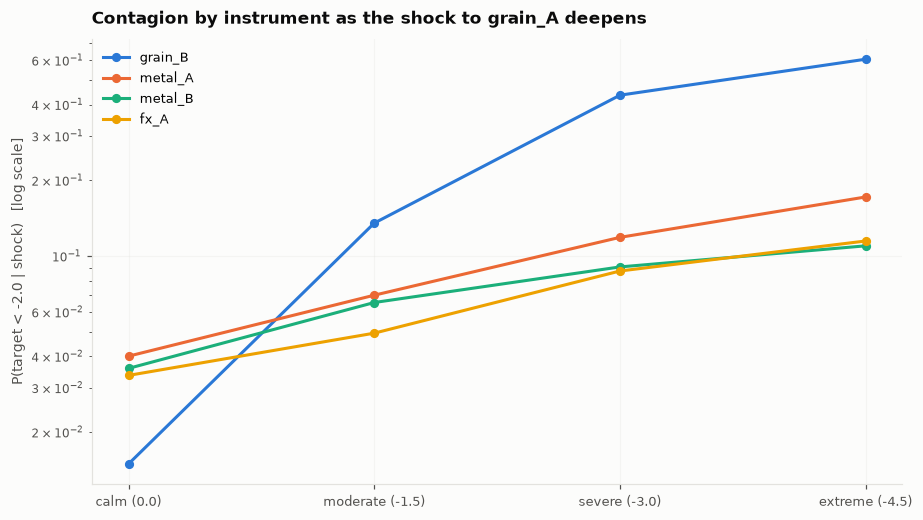

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(scenarios))
palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
for color, target in zip(palette, targets):
    ax.plot(x, stress[target].values, marker="o", color=color, label=target)
ax.set_yscale("log")
ax.set_xticks(x, list(scenarios), fontsize=8.5)
ax.set_ylabel("P(target < -2.0 | shock)   [log scale]")
ax.set_title("Contagion by instrument as the shock to grain_A deepens", loc="left",
             fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

A log y-axis, because these probabilities span orders of magnitude. The slope of each line is
the thing to read: steep means strongly coupled to the shocked instrument, flat means
insulated.

## Full conditional distributions

A probability is a summary. The whole conditional distribution shows how the *shape* changes,
not just the mass past a threshold.

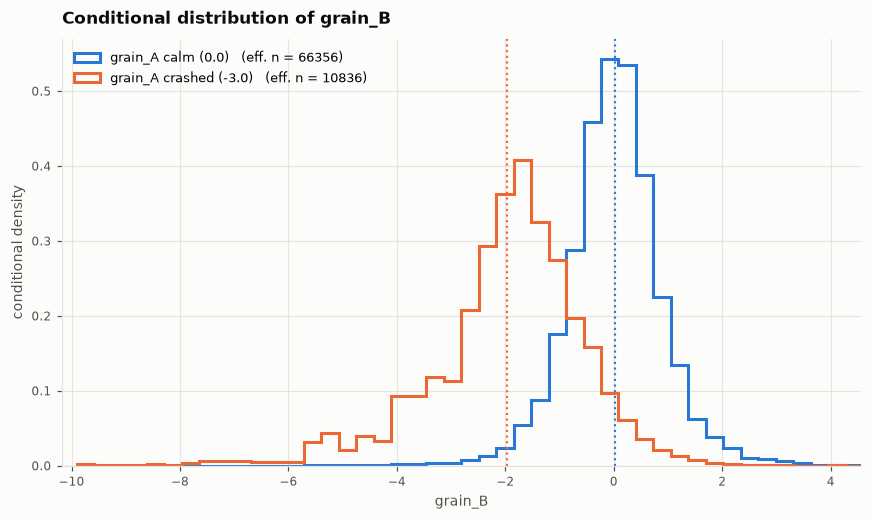

In [6]:
fig = ncplot.plot_conditional_distribution(
    model, target="grain_B",
    given_list=[{"grain_A": 0.0}, {"grain_A": -3.0}],
    labels=["grain_A calm (0.0)", "grain_A crashed (-3.0)"],
    tol=0.35, n_mc=150_000,
)
plt.show()

Conditioning on the crash does not simply translate the distribution left — it changes its
shape, concentrating mass in the lower tail. Dotted vertical lines mark the conditional means.

## Conditional VaR

The same machinery gives conditional quantiles directly, which is what a value-at-risk
calculation needs.

In [7]:
rows = []
for label, shock in scenarios.items():
    q = model.conditional_quantiles("grain_B", given={"grain_A": shock},
                                    quantiles=(0.01, 0.05, 0.25, 0.5),
                                    tol=0.35, n_mc=150_000)
    rows.append(pd.Series(q.values, index=[f"q{int(p*100):02d}" for p in q.index], name=label))

var_table = pd.DataFrame(rows)
var_table["5% VaR shift vs calm"] = var_table["q05"] - var_table.loc["calm (0.0)", "q05"]
var_table.round(3)

,q01,q05,q25,q50,5% VaR shift vs calm
calm (0.0),-2.181,-1.329,-0.476,0.002,0.000
moderate (-1.5),-4.625,-2.774,-1.615,-1.025,-1.444
severe (-3.0),-6.675,-4.681,-2.630,-1.800,-3.352
extreme (-4.5),-8.270,-5.418,-3.547,-2.384,-4.089


The last column is the number a risk manager wants: how much further the 5% worst case moves
once the shock is known. Under the extreme scenario the conditional VaR shifts substantially
— a capital requirement computed unconditionally would be badly wrong precisely when it
matters.

## Conditioning on several variables at once

Kernel weights multiply, so multiple conditions compose naturally. Note that each added
condition cuts the effective sample size, so widen `tol` or raise `n_mc` accordingly.

In [8]:
rows = []
for label, given in {
    "grain_A alone":          {"grain_A": -3.0},
    "grain_A + grain_B":      {"grain_A": -3.0, "grain_B": -3.0},
    "grain_A + metal_A":      {"grain_A": -3.0, "metal_A": -3.0},
}.items():
    p, ess = model.conditional_probability("metal_B", "<", -2.0, given=given,
                                           tol=0.5, n_mc=250_000)
    rows.append({"conditioning on": label, "P(metal_B < -2)": p, "effective n": ess})
pd.DataFrame(rows).set_index("conditioning on").round(4)

,P(metal_B < -2),effective n
conditioning on,,
grain_A alone,0.0863,30441.2957
grain_A + grain_B,0.0945,14016.6203
grain_A + metal_A,0.2953,4972.5507


Adding `metal_A` to the conditioning set moves `metal_B`'s crash probability far more than
adding `grain_B` does — `metal_B`'s own block carries the information. Watch the effective
sample size fall as conditions are added; that is the cost of asking a sharper question.

## Sanity check against the data

Model-based conditionals are only worth having if they agree with the data where the data is
dense enough to check. Here we compare against a simple empirical window.

In [9]:
rows = []
for shock, width in [(0.0, 0.5), (-1.5, 0.75), (-3.0, 1.0)]:
    window = df[(df.grain_A > shock - width) & (df.grain_A < shock + width)]
    model_p, ess = model.conditional_probability(
        "grain_B", "<", -2.0, given={"grain_A": shock}, tol=0.35, n_mc=150_000)
    rows.append({
        "shock": shock,
        "rows in window": len(window),
        "empirical": float((window.grain_B < -2.0).mean()) if len(window) else np.nan,
        "model": model_p,
        "model effective n": ess,
    })
pd.DataFrame(rows).set_index("shock").round(4)

,rows in window,empirical,model,model effective n
shock,,,,
0.0,1444,0.0097,0.0138,66416.9787
-1.5,817,0.0967,0.1355,35056.7832
-3.0,197,0.4569,0.4346,10987.7012


The model tracks the empirical estimate closely where the window holds enough rows. Note how
few rows fall in the deepest window — that scarcity is exactly why a fitted model is useful:
it borrows structure from the whole dataset instead of relying on the handful of historical
observations near the conditioning point.

## Takeaways

1. **Always check the effective sample size.** It is reported everywhere for a reason.
2. **Sweep `tol` before trusting a number.** Stable across the middle range means the estimate
   is real; jumping around means it is noise.
3. **Conditional probabilities communicate better than coefficients.** "The crash probability
   goes from 0.2% to 60%" lands where "λ_L = 0.71" does not.
4. **Contagion is instrument-specific and shock-dependent** — the whole point of fitting a
   joint rather than a correlation matrix.
5. **Cross-check against empirical windows** where the data is dense enough to allow it.